# Introdução ao Dash para Construção de Dashboards em Python


## Visão geral da aula

Nesta aula vamos conhecer o **Dash**, um framework em Python para criação de **dashboards interativos** na Web, aproveitando os conhecimentos que você já tem de **Python**, **Pandas**, **visualização de dados** e **HTML/CSS**.


## Conceitos fundamentais

### O que é o Dash?

- **Dash** é um framework em Python, desenvolvido pela Plotly, para criar **aplicações web interativas** voltadas para visualização e análise de dados.
- Permite que você escreva toda a **lógica em Python**, sem precisar programar em JavaScript.
- É muito usado para construir **dashboards** para times de negócios, gestores e clientes.
- Documentação está disponível aqui: https://dash.plotly.com/tutorial

### Para que serve o Dash?

- Criação de **dashboards interativos** para:
  - Monitoramento de indicadores (KPIs).
  - Análise exploratória interativa.
  - Relatórios dinâmicos para tomada de decisão.
- Substitui ou complementa relatórios estáticos (PDF, slides), permitindo que o usuário **brinque com filtros e opções**.

### Dash x Matplotlib / Seaborn

- **Matplotlib/Seaborn**:
  - Focam em **gráficos estáticos** (imagens) exibidos em notebooks ou salvos em arquivos.
  - Interações são limitadas e locais (zoom, pan) e geralmente não são pensadas para usuários finais.
- **Dash**:
  - Cria **aplicações web completas**, com layout, componentes de interface e lógica de interação.
  - Facilita a **publicação** de dashboards para usuários não técnicos acessarem via navegador.

### Relação com Python, HTML, CSS e componentes visuais

- **Python**: linguagem usada para escrever o app (carregar dados, processar, definir layout, callbacks).
- **HTML**: o layout do Dash é definido com componentes que representam tags HTML, por exemplo:
  - `html.Div` → `<div>`
  - `html.H1` → `<h1>`
  - `html.P` → `<p>`
- **CSS**: controla aparência (cores, margens, fontes, alinhamento), via:
  - `style={...}` direto nos componentes, ou
  - arquivos `.css` em uma pasta `assets/`.
- **Componentes visuais (Dash Core Components)**:
  - `dcc.Graph` (gráficos interativos com Plotly).
  - `dcc.Dropdown`, `dcc.Slider`, `dcc.Checklist`, `dcc.RadioItems` etc.

### Interatividade e callbacks

- A interatividade é implementada usando **callbacks**, que são funções Python decoradas com `@app.callback`.
- Um callback:
  - Recebe valores de **componentes de entrada** (`Input`), como dropdowns e sliders.
  - Produz valores para **componentes de saída** (`Output`), como gráficos ou textos.

### Conceito de dashboard

- Um **dashboard** é uma tela que apresenta **informações relevantes** de forma visual, resumida e muitas vezes interativa.
- Em Ciência de Dados, dashboards permitem:
  - **Resumir análises complexas** em gráficos e indicadores.
  - Apoiar a **tomada de decisão** por usuários de negócio.
  - Explorar diferentes cortes dos dados (por tempo, região, categoria etc.).

### Casos de uso em Ciência de Dados

- Dashboard de vendas por região, produto e período.
- Painel de marketing digital (cliques, conversões, custo por canal).
- Monitoramento de indicadores de saúde (casos, óbitos, ocupação de leitos).
- Painéis de performance operacional (máquinas, logística, transporte).

## Observação sobre uso do Dash em Jupyter Notebook

- O Dash foi pensado originalmente para rodar como um **servidor web** independente, acessado pelo navegador (por exemplo, em `http://127.0.0.1:8050`).
- Em um **script `.py`** típico, rodamos o servidor com:
  
  ```python
  if __name__ == "__main__":
      app.run_server(debug=True)
  ```

- Em **Jupyter Notebook**, algumas observações importantes:
  - O comando `app.run_server()` ocupa a célula enquanto o servidor está rodando.
  - Você acessa o dashboard em uma aba do navegador, na porta indicada (por padrão, 8050).

## Exemplo 1 – Instalação e estrutura mínima do app Dash

Nesta primeira etapa, vamos:
- Garantir que o Dash esteja instalado.
- Criar a **estrutura mínima** de uma aplicação Dash.

> **Obs.:** a instalação (`pip install`) normalmente é feita no terminal, mas pode ser chamada a partir do notebook com `!pip install ...`.

In [ ]:
# (Opcional) Instalação das bibliotecas necessárias
# Execute esta célula se ainda não tiver as bibliotecas instaladas no ambiente.

!pip install dash plotly

In [ ]:
# Exemplo 1: estrutura mínima de um app Dash

# Dash → responsável por criar a aplicação
# html → permite usar componentes HTML (como div, h1, p, etc.)
from dash import Dash, html

# Criação da aplicação Dash
app = Dash()

# Definição do layout da aplicação
# O layout representa a "estrutura visual" da página (interface do usuário).
# Tudo que será exibido na tela precisa estar dentro do layout.
# Aqui usamos um único componente: um título (H1) e um parágrafo (P).
app.layout = html.Div(
    children=[
        html.H1("Meu primeiro app Dash em Ciência de Dados"),
        html.P("Este é um parágrafo de texto simples no layout.")
    ]
)

# Execução da aplicação
# O método run() inicia o servidor local para visualizar o app no navegador.
# debug=True:
# - Atualiza automaticamente a página ao salvar alterações (hot reload)
# - Exibe mensagens de erro mais detalhadas (ótimo para aprendizado)
app.run(debug=True)

## Exemplo 2 – Dashboard mínimo com título, texto e gráfico

Agora vamos construir um dashboard simples com:
- Um título
- Um texto explicativo
- Um gráfico de dispersão mostrando a relação entre `total_bill` e `tip` usando o dataset `tips` do Seaborn.

O objetivo é entender **como um gráfico Plotly é incorporado ao layout do Dash**.

Link para gráficos da biblioteca plotly: https://plotly.com/python/plotly-express/

## Comparação: Plotly Express vs Graph Objects

| Característica | Plotly Express | Plotly Graph Objects |
|---|---|---|
| Nível de abstração | Alto nível | Baixo nível |
| Facilidade de uso | Muito fácil | Mais complexo |
| Quantidade de código | Pouco código | Mais verboso |
| Integração com Pandas | Direta (usa DataFrames facilmente) | Precisa acessar colunas manualmente |
| Flexibilidade | Média | Muito alta |
| Controle sobre o gráfico | Limitado a parâmetros da função | Controle total sobre cada elemento |
| Uso típico | Análise exploratória de dados | Dashboards mais customizados |
| Velocidade para criar gráficos | Muito rápida | Mais demorada |
| Curva de aprendizado | Baixa | Maior |
| Uso em Dash | Muito comum | Usado quando é necessário maior personalização |

In [ ]:
# Exemplo 2: dashboard mínimo com gráfico simples

# Importação do módulo dcc (Dash Core Components)
# Ele contém componentes mais avançados, como gráficos, inputs, sliders, etc.

from dash import Dash, html, dcc
import plotly.express as px
import seaborn as sns

# Carregar o dataset tips (Seaborn)
tips = sns.load_dataset("tips")
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


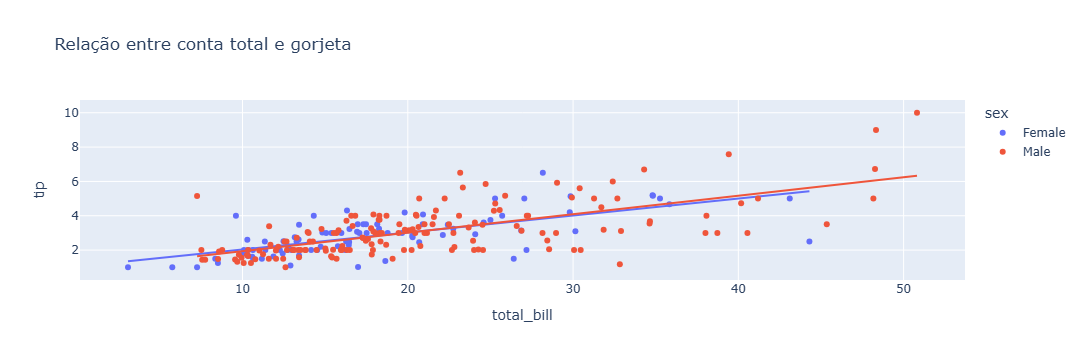

In [ ]:
# Criar um gráfico de dispersão simples
fig_scatter = px.scatter(
    tips,
    x="total_bill",
    y="tip",
    title="Relação entre conta total e gorjeta",
    color="sex",
    trendline="ols"
)
fig_scatter

In [ ]:
# Criar a aplicação Dash
app = Dash()

# Definir o layout com título, texto e gráfico
app.layout = html.Div(
    children=[
        html.H1("Dashboard de Gorjetas - Exemplo Simples"),
        html.P("Este dashboard mostra a relação entre o valor da conta e a gorjeta."),
       
        # dcc.Graph → componente responsável por renderizar gráficos no Dash
        dcc.Graph(
            id="grafico-conta-gorjeta",
            figure=fig_scatter
        )
    ]
)

app.run(debug=True)

## Exemplo 3 – Layout com múltiplos componentes

Vamos agora organizar **dois gráficos** no mesmo dashboard, cada um em seu bloco (`html.Div`), para reforçar a ideia de layout como "caixas" de conteúdo empilhadas.

Criaremos:
- Um gráfico de dispersão (`total_bill` x `tip`).
- Um gráfico de barras com a **gorjeta média por dia da semana**.

In [ ]:
# Exemplo 3: layout com múltiplos gráficos

from dash import Dash, html, dcc
import plotly.express as px
import seaborn as sns

# Carregar dataset tips
tips = sns.load_dataset("tips")

# Gráfico de dispersão (reaproveitado do exemplo anterior)
fig_scatter = px.scatter(
    tips,
    x="total_bill",
    y="tip",
    title="Relação entre conta total e gorjeta",
    color="sex"
)

# Gráfico de barras: gorjeta média por dia
fig_bar = px.bar(
    tips,
    x="day",
    y="tip",
    color="day",
    title="Gorjeta média por dia da semana",
    labels={"day": "Dia da semana", "tip": "Gorjeta"}
)

app = Dash()

app.layout = html.Div(
    children=[
        html.H1("Dashboard de Gorjetas - Múltiplos Gráficos"),

        html.Div(
            children=[
                html.H2("Relação Conta x Gorjeta"),
                dcc.Graph(
                    id="grafico-scatter",
                    figure=fig_scatter
                )
            ]
        ),

        html.Div(
            children=[
                html.H2("Gorjeta média por dia"),
                dcc.Graph(
                    id="grafico-barra",
                    figure=fig_bar
                )
            ]
        )
    ]
)

app.run(debug=True)

## Exemplo 4 – Uso de CSS e organização visual (colunas)

Agora vamos usar CSS inline (`style={...}`) para:
- Centralizar o título.
- Colocar **dois gráficos lado a lado** (duas colunas).
- Ajustar margens, cores de fundo e fonte.

A ideia aqui é mostrar como `html.Div` + `style` podem ser usados para criar **layouts mais agradáveis**.

In [ ]:
# Exemplo 4: layout com CSS inline (duas colunas)

from dash import Dash, html, dcc
import plotly.express as px
import seaborn as sns

# Carregar dataset tips
tips = sns.load_dataset("tips")

fig_scatter = px.scatter(
    tips,
    x="total_bill",
    y="tip",
    title="Relação entre conta total e gorjeta",
    color="sex"
)

fig_bar = px.bar(
    tips,
    x="day",
    y="tip",
    color="day",
    title="Gorjeta média por dia da semana",
    labels={"day": "Dia da semana", "tip": "Gorjeta"}
)

app = Dash()

app.layout = html.Div(
    children=[
        html.H1(
            "Dashboard de Gorjetas - Layout com CSS",
            style={
                "textAlign": "center",
                "color": "#333333"
            }
        ),

        html.P(
            "Exemplo de organização em colunas usando CSS inline.",
            style={"textAlign": "center"}
        ),

        html.Div(
            children=[
                # Coluna 1
                html.Div(
                    children=[
                        html.H2("Relação Conta x Gorjeta"),
                        dcc.Graph(
                            id="grafico-scatter-css",
                            figure=fig_scatter
                        )
                    ],
                    style={
                        "width": "48%",
                        "display": "inline-block",
                        "verticalAlign": "top",
                        "padding": "0 10px"
                    }
                ),

                # Coluna 2
                html.Div(
                    children=[
                        html.H2("Gorjeta média por dia"),
                        dcc.Graph(
                            id="grafico-barra-css",
                            figure=fig_bar
                        )
                    ],
                    style={
                        "width": "48%",
                        "display": "inline-block",
                        "verticalAlign": "top",
                        "padding": "0 10px"
                    }
                )
            ],
            style={
                "textAlign": "center"
            }
        )
    ],
    style={
        "fontFamily": "Arial, sans-serif",
        "margin": "0 auto",
        "padding": "20px",
        "backgroundColor": "#f7f7f7"
    }
)

app.run(debug=True)

## Exemplo 5 – Componentes interativos

Nesta etapa vamos inserir componentes interativos no layout, mas **ainda sem conectá-los a gráficos**:
- `Dropdown`
- `RadioItems`
- `Checklist`
- `Slider`

Objetivo: entender a aparência e os parâmetros básicos desses componentes.

In [ ]:
# Exemplo 5: adicionando componentes interativos no layout (sem callbacks)

from dash import Dash, html, dcc
import seaborn as sns

# Carregar dataset tips (apenas para usar valores em opções)
tips = sns.load_dataset("tips")

app = Dash()

app.layout = html.Div(
    children=[
        html.H1("Dashboard de Gorjetas - Componentes Interativos"),

        html.Div(
            children=[
                html.Label("Selecione o dia da semana:"),
                # dcc.Dropdown → componente de seleção (lista suspensa)
                # options → lista de opções disponíveis
                # cada opção é um dicionário com:
                # label → texto exibido
                # value → valor interno utilizado pelo Dash
                dcc.Dropdown(
                    id="dropdown-dia",
                    options=[{"label": dia, "value": dia} for dia in tips["day"].unique()],
                    value="Sun",  # valor inicial
                    clearable=False # clearable=False → impede que o usuário remova a seleção
                )
            ],
            style={"marginBottom": "20px"}
        ),

        html.Div(
            children=[
                html.Label("Selecione o sexo:"),
                # dcc.RadioItems → seleção única (botões de opção)
                dcc.RadioItems(
                    id="radio-sexo",
                    options=[
                        {"label": "Masculino", "value": "Male"},
                        {"label": "Feminino", "value": "Female"}
                    ],
                    value="Male",
                    inline=True
                )
            ],
            style={"marginBottom": "20px"}
        ),

        html.Div(
            children=[
                
                html.Label("Filtrar por fumantes:"),
                # dcc.Checklist → permite múltiplas seleções
                dcc.Checklist(
                    id="checklist-fumante",
                    options=[
                        {"label": "Fumantes", "value": "Yes"},
                        {"label": "Não fumantes", "value": "No"}
                    ],
                    # value é uma LISTA (pois pode selecionar múltiplos)
                    value=["Yes", "No"],
                    inline=True
                )
            ],
            style={"marginBottom": "20px"}
        ),

        html.Div(
            children=[
                html.Label("Tamanho mínimo da mesa (número de pessoas):"),
                # dcc.Slider → componente de seleção numérica contínua/discreta
                dcc.Slider(
                    id="slider-tamanho",
                    min=int(tips["size"].min()),
                    max=int(tips["size"].max()),
                    step=1,
                    value=2,
                    # As chaves do dicionário 'marks' precisam ser tipos simples (int/str).
                    # Aqui convertemos explicitamente para int para evitar erro de numpy.int64.
                    marks={int(i): str(int(i)) for i in sorted(tips["size"].unique())}
                )
            ],
            style={"marginBottom": "40px"}
        ),

        html.Div(
            children=[
                html.P("Os componentes acima ainda não estão conectados a nenhum gráfico."),
                html.P("No próximo exemplo, vamos criar callbacks para torná-los interativos.")
            ]
        )
    ],
    style={"padding": "20px"}
)

app.run(debug=True)

## Exemplo 6 – Callbacks: conectando interação e gráficos

Agora vamos ligar um componente interativo a um gráfico usando **callbacks**.

### Ideia do exemplo

- Ter um `Dropdown` para escolher o **dia da semana**.
- Atualizar um gráfico de dispersão (`total_bill` x `tip`) filtrado pelo dia selecionado.

### Conceito de callback

- Um callback é uma função Python decorada com `@app.callback`.
- Você declara quais componentes são **entrada** (`Input`) e quais são **saída** (`Output`).
- Sempre que um Input muda, o Dash executa a função e atualiza o Output.

In [ ]:
# Exemplo 6: callback simples para filtrar gráfico por dia da semana

from dash import Dash, html, dcc
from dash.dependencies import Input, Output
import plotly.express as px
import seaborn as sns

# Carregar dataset tips
tips = sns.load_dataset("tips")

app = Dash()

app.layout = html.Div(
    children=[
        html.H1("Dashboard de Gorjetas - Callback Simples"),

        html.Label("Selecione o dia da semana:"),
        dcc.Dropdown(
            id="dropdown-dia-callback",
            options=[{"label": dia, "value": dia} for dia in tips["day"].unique()],
            value="Sun",
            clearable=False
        ),

        dcc.Graph(id="grafico-filtrado")
    ],
    style={"padding": "20px"}
)

# @app.callback → decorador que conecta entradas e saídas
# Sempre que o Input mudar, essa função será executada automaticamente
@app.callback(
    # "Atualize a propriedade 'figure' do componente 'grafico-filtrado'"
    Output("grafico-filtrado", "figure"),  # componente de saída: o gráfico
    # "Observe mudanças no valor selecionado do dropdown"
    Input("dropdown-dia-callback", "value")  # componente de entrada: valor do dropdown
)
def atualizar_grafico(dia_selecionado):
    """Filtra o DataFrame pelo dia selecionado e retorna uma figura Plotly."""
    df_filtrado = tips[tips["day"] == dia_selecionado]

    fig = px.scatter(
        df_filtrado,
        x="total_bill",
        y="tip",
        color="sex",
        title=f"Relação Conta x Gorjeta - Dia: {dia_selecionado}"
    )
    return fig


app.run(debug=True)

## Exemplo 7 – Mini dashboard completo (tipo projeto final reduzido)

Neste exemplo, vamos montar um **mini dashboard completo** usando o dataset `tips`:

- Filtros:
  - Dia da semana (`Dropdown`).
  - Sexo (`RadioItems`).
  - Fumante (`Checklist`).
- Gráficos:
  - Dispersão `total_bill` x `tip` (colorido por dia).
  - Barras com **gorjeta média por dia**.

Objetivo: aproximar o que seria um **projeto final de dashboard**, combinando layout, filtros e callbacks.

In [ ]:
# Exemplo 7: mini dashboard completo com múltiplos filtros e gráficos

from dash import Dash, html, dcc
from dash.dependencies import Input, Output
import plotly.express as px
import seaborn as sns

# Carregar dataset tips
tips = sns.load_dataset("tips")

app = Dash()

app.layout = html.Div(
    children=[
        html.H1(
            "Dashboard de Gorjetas - Mini Projeto",
            style={"textAlign": "center"}
        ),

        html.Div(
            children=[
                # Coluna de filtros
                html.Div(
                    children=[
                        html.H3("Filtros"),

                        html.Label("Dia da semana:"),
                        dcc.Dropdown(
                            id="filtro-dia",
                            options=[{"label": dia, "value": dia} for dia in tips["day"].unique()],
                            value=None,
                            placeholder="Selecione um dia (ou deixe em branco para todos)",
                            clearable=True
                        ),

                        html.Br(),

                        html.Label("Sexo:"),
                        dcc.RadioItems(
                            id="filtro-sexo",
                            options=[
                                {"label": "Todos", "value": "Todos"},
                                {"label": "Masculino", "value": "Male"},
                                {"label": "Feminino", "value": "Female"}
                            ],
                            value="Todos"
                        ),

                        html.Br(),

                        html.Label("Fumante:"),
                        dcc.Checklist(
                            id="filtro-fumante",
                            options=[
                                {"label": "Fumantes", "value": "Yes"},
                                {"label": "Não fumantes", "value": "No"}
                            ],
                            value=["Yes", "No"]
                        )
                    ],
                    style={
                        "width": "25%",
                        "display": "inline-block",
                        "verticalAlign": "top",
                        "padding": "20px",
                        "backgroundColor": "#f0f0f0"
                    }
                ),

                # Coluna de gráficos
                html.Div(
                    children=[
                        html.H3("Relação Conta x Gorjeta"),
                        dcc.Graph(id="grafico-dispersao"),

                        html.H3("Gorjeta média por dia"),
                        dcc.Graph(id="grafico-media-dia")
                    ],
                    style={
                        "width": "70%",
                        "display": "inline-block",
                        "verticalAlign": "top",
                        "padding": "20px"
                    }
                )
            ]
        )
    ],
    style={"fontFamily": "Arial, sans-serif"}
)


@app.callback(
    [Output("grafico-dispersao", "figure"),
     Output("grafico-media-dia", "figure")],
    [Input("filtro-dia", "value"),
     Input("filtro-sexo", "value"),
     Input("filtro-fumante", "value")]
)
def atualizar_dash(dia, sexo, lista_fumante):
    """Filtra o DataFrame 'tips' de acordo com os filtros e retorna duas figuras Plotly."""
    df = tips.copy()

    # Filtro por dia
    if dia is not None:
        df = df[df["day"] == dia]

    # Filtro por sexo
    if sexo != "Todos":
        df = df[df["sex"] == sexo]

    # Filtro por fumante
    if lista_fumante:
        df = df[df["smoker"].isin(lista_fumante)]
    else:
        # Se nada selecionado, DataFrame vazio (sem dados para mostrar)
        df = df.iloc[0:0]

    # Gráfico de dispersão
    fig_disp = px.scatter(
        df,
        x="total_bill",
        y="tip",
        color="day",
        hover_data=["sex", "smoker", "size"],
        title="Dispersão: Conta x Gorjeta (filtrada)"
    )

    # Gráfico de gorjeta média por dia
    if not df.empty:
        df_media = df.groupby("day", as_index=False)["tip"].mean()
    else:
        df_media = df.copy()

    fig_media = px.bar(
        df_media,
        x="day",
        y="tip",
        title="Gorjeta média por dia (filtrada)",
        labels={"day": "Dia", "tip": "Gorjeta média"}
    )

    return fig_disp, fig_media


app.run(debug=True)


## Materiais complementares sugeridos

- **Documentação oficial do Dash (Plotly)** – tutoriais e exemplos práticos. https://plotly.com/python/
- **Galeria de dashboards Dash** – para inspiração de layout e interatividade. https://plotly.com/examples/
- **Documentação Plotly Express** – referência para tipos de gráficos.
- **Biblioteca Humanize** - https://pypi.org/project/humanize/
